In [1]:
import pyscf
import openfermionpyscf
import openfermion as of
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [11]:
dists = np.linspace(0.6, 5, 28)

orbenes = np.zeros((4, len(dists)))

for i, dist in tqdm(enumerate(dists)):

    
    # geometry = [["Li", (0, 0, 0)],
    #             ["H", (0, 0, dist)]]
    geometry = [["H", (0, 0, 0)],
                ["H", (0, 0, dist)],
                ["H", (0, 0, 2 * dist)],
                ["H", (0, 0, 3 * dist)]]
    
    mol = of.MolecularData(
            geometry=geometry,
            basis="sto-3g",
            multiplicity=1,
            charge=0
        )
    mol = openfermionpyscf.run_pyscf(mol, run_scf=True, run_fci=False, run_cisd=False)
    orbenes[:, i] = mol.orbital_energies

28it [00:01, 16.11it/s]


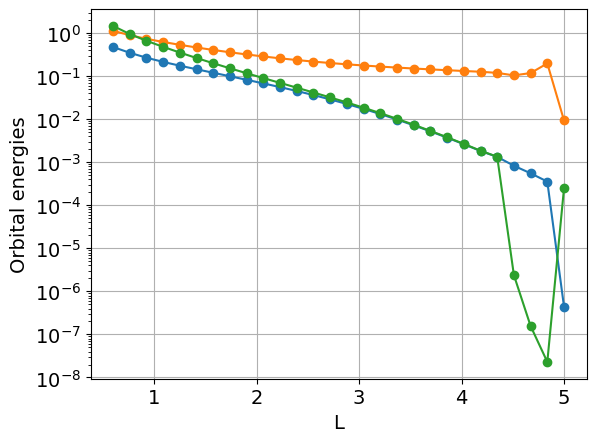

In [16]:
plt.rcParams.update({"font.size":14})
# plt.plot(dists, orbenes[0, :], "o-")
# plt.plot(dists, orbenes[1, :], "o-")
# plt.plot(dists, orbenes[2, :], "o-")
# plt.plot(dists, orbenes[3, :], "o-")
# plt.plot(dists, orbenes[4, :], "o-")
# plt.plot(dists, orbenes[5, :], "o-")
plt.plot(dists, orbenes[1, :] - orbenes[0, :], "o-")
plt.plot(dists, orbenes[2, :] - orbenes[1, :], "o-")
plt.plot(dists, orbenes[3, :] - orbenes[2, :], "o-")
plt.xlabel("L")
plt.ylabel("Orbital energies")
plt.yscale("log")
plt.grid()

In [10]:
dists

array([0.6       , 0.84444444, 1.08888889, 1.33333333, 1.57777778,
       1.82222222, 2.06666667, 2.31111111, 2.55555556, 2.8       ,
       3.04444444, 3.28888889, 3.53333333, 3.77777778, 4.02222222,
       4.26666667, 4.51111111, 4.75555556, 5.        ])

In [15]:
print(mol.orbital_energies)
print(mol.orbital_energies[2] - mol.orbital_energies[1])

[-2.10244138e+00 -3.28480474e-01  1.16027857e-03  3.02784897e-01
  3.02784897e-01  3.03493832e-01]
0.329640752856988
